# Tutorial 03: Complete DP-SGD Training Loop

**Level**: Intermediate
**Duration**: 45-60 minutes
**Prerequisites**: Tutorial 01 (Gradient Clipping), Tutorial 02 (Noise & Accounting)

---

## Overview

In this tutorial, we put everything together to implement a complete **DP-SGD training loop**.

**What you've learned so far**:
- **Tutorial 01**: Gradient clipping with `clipped_grad()`
- **Tutorial 02**: Noise injection with `add_gaussian_noise()` and privacy accounting

**What you'll build today**:
1. Complete DP-SGD training loop
2. Compare DP-SGD vs non-private training
3. Visualize privacy-utility tradeoffs
4. Track privacy budget throughout training

**The DP-SGD Algorithm** (recap):
```python
for batch in dataloader:
    # 1. Compute clipped gradients (Tutorial 01)
    clipped_grads = clipped_grad_fn(params, batch)

    # 2. Add calibrated noise (Tutorial 02)
    noisy_grads = add_gaussian_noise(clipped_grads, stddev)

    # 3. Update parameters
    params = optimizer_step(params, noisy_grads)

    # 4. Track privacy (Tutorial 02)
    accountant.step_poisson(noise_multiplier, sample_rate)
    epsilon = accountant.get_epsilon(target_delta)
```

Let's build this!

---

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

# Opaque imports
from opaque import (
  clipped_grad,
  add_gaussian_noise,
  RDPAccountant,
  calibrate_noise_multiplier,
)

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print("Opaque imported successfully!")

PyTorch version: 2.9.0
Opaque imported successfully!


## Part 1: Setup - Data and Model

Let's create a simple binary classification problem to demonstrate DP-SGD.

In [21]:
# Generate synthetic binary classification data
def generate_data(n_samples=1000, n_features=20, seed=42):
  torch.manual_seed(seed)
  X = torch.randn(n_samples, n_features)
  # Simple decision boundary: positive if first feature > 0
  y = (X[:, 0] + 0.5 * X[:, 1] > 0).float()
  return X, y


# Generate training data
X_train, y_train = generate_data(n_samples=10000)
X_test, y_test = generate_data(n_samples=300, seed=123)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {X_train.shape[1]}")
print(f"\nClass balance: {y_train.mean().item():.2%} positive")

Training samples: 10000
Test samples: 300
Features: 20

Class balance: 49.69% positive


In [22]:
# Initialize model parameters (logistic regression)
n_features = X_train.shape[1]
params_init = {
  'weight': torch.randn(n_features, 1) * 0.01,
  'bias': torch.zeros(1),
}


# Define loss function
# Note: x and y are separate arguments for vmap to work correctly
def loss_fn(params, x, y):
  """Binary cross-entropy loss for logistic regression."""
  logits = x @ params['weight'] + params['bias']
  return F.binary_cross_entropy_with_logits(logits.squeeze(-1), y)


print("Model: Logistic Regression")
print(f"Parameters: weight {params_init['weight'].shape}, bias {params_init['bias'].shape}")

Model: Logistic Regression
Parameters: weight torch.Size([20, 1]), bias torch.Size([1])


## Part 2: DP-SGD Configuration

Let's set up our DP-SGD hyperparameters and calibrate the noise multiplier.

In [55]:
# DP-SGD hyperparameters
target_epsilon = 3.0
target_delta = 0.5e-5
l2_clip_norm = 1.0
batch_size = 50
n_epochs = 40
learning_rate = 0.1

# Calculate training configuration
sample_rate = batch_size / len(X_train)
steps_per_epoch = len(X_train) // batch_size
total_steps = n_epochs * steps_per_epoch

print(f"Training Configuration:")
print(f"  Batch size: {batch_size}")
print(f"  Sample rate: {sample_rate:.4f}")
print(f"  Steps per epoch: {steps_per_epoch}")
print(f"  Total steps: {total_steps}")
print(f"\nPrivacy Target:")
print(f"  Target ε: {target_epsilon}")
print(f"  Target δ: {target_delta}")

Training Configuration:
  Batch size: 50
  Sample rate: 0.0050
  Steps per epoch: 200
  Total steps: 8000

Privacy Target:
  Target ε: 3.0
  Target δ: 5e-06


In [56]:
# Calibrate noise multiplier for target privacy
noise_multiplier = calibrate_noise_multiplier(
  target_epsilon=target_epsilon,
  target_delta=target_delta,
  sample_rate=sample_rate,
  num_steps=total_steps,
  accountant_type="rdp",  # Fast
)

stddev = noise_multiplier * l2_clip_norm

print(f"Calibrated noise multiplier: {noise_multiplier:.4f}")
print(f"Noise stddev: {stddev:.4f}")
print(f"Clip norm: {l2_clip_norm}")
print(f"\n✓ This noise will achieve (ε={target_epsilon}, δ={target_delta})-DP")

Calibrated noise multiplier: 0.9775
Noise stddev: 0.9775
Clip norm: 1.0

✓ This noise will achieve (ε=3.0, δ=5e-06)-DP


## Part 3: DP-SGD Training Loop

Now let's implement the complete DP-SGD training loop using all our APIs.

In [57]:
def train_dp_sgd(
  params,
  X, y,
  batch_size=50,
  n_epochs=20,
  learning_rate=0.1,
  l2_clip_norm=1.0,
  noise_multiplier=1.0,
  sample_rate=0.05,
  target_delta=1e-5,
  use_dp=True,
):
  """Train with DP-SGD or standard SGD.

  Args:
      params: Initial parameters (PyTree)
      X, y: Training data
      use_dp: If True, use DP-SGD; if False, use standard SGD

  Returns:
      params: Final parameters
      losses: Loss per epoch
      epsilons: Privacy spent per epoch (if use_dp)
  """
  # Make a copy of parameters
  params = {k: v.clone() for k, v in params.items()}

  # Create clipped gradient function
  # batch_argnums=(1, 2) means both x (arg 1) and y (arg 2) have batch dimension
  clipped_grad_fn = clipped_grad(
    loss_fn,
    argnums=0,
    batch_argnums=(1, 2),  # Both x and y are batched
    l2_clip_norm=l2_clip_norm,
  )

  # Create privacy accountant
  accountant = RDPAccountant() if use_dp else None

  # Noise generator
  noise_gen = torch.Generator().manual_seed(42)
  stddev = noise_multiplier * l2_clip_norm

  losses = []
  epsilons = []

  steps_per_epoch = len(X) // batch_size

  # Training loop
  for epoch in range(n_epochs):
    # Shuffle data
    perm = torch.randperm(len(X))
    X_shuffled = X[perm]
    y_shuffled = y[perm]

    epoch_loss = 0.0
    n_batches = 0

    for i in range(0, len(X), batch_size):
      # Get batch
      X_batch = X_shuffled[i:i + batch_size]
      y_batch = y_shuffled[i:i + batch_size]

      # Step 1: Compute clipped gradients (summed over batch)
      # Pass x and y as separate arguments
      grads = clipped_grad_fn(params, X_batch, y_batch)

      # Step 2: Add noise (if DP)
      if use_dp:
        grads = add_gaussian_noise(grads, stddev=stddev, generator=noise_gen)

      # Step 3: Update parameters
      batch_size_actual = len(X_batch)
      for key in params:
        params[key] = params[key] - (learning_rate / batch_size_actual) * grads[key]

      # Compute loss for logging
      with torch.no_grad():
        loss = loss_fn(params, X_batch, y_batch)
        epoch_loss += loss.item()
        n_batches += 1

    # 🚀 PERFORMANCE: Account once per epoch, not per step (130x faster!)
    if use_dp:
      accountant.step_poisson(
        noise_multiplier=noise_multiplier,
        sample_rate=sample_rate,
        num_steps=steps_per_epoch,  # Batch all steps in this epoch
      )

    # Record metrics
    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)

    if use_dp:
      epsilon = accountant.get_epsilon(target_delta=target_delta)
      epsilons.append(epsilon)

    # Print progress
    if (epoch + 1) % 5 == 0:
      if use_dp:
        print(f"Epoch {epoch + 1}/{n_epochs}: loss={avg_loss:.4f}, ε={epsilon:.2f}")
      else:
        print(f"Epoch {epoch + 1}/{n_epochs}: loss={avg_loss:.4f}")

  return params, losses, epsilons


print("✓ DP-SGD training function defined")

✓ DP-SGD training function defined


### ⚡ Performance Optimization

**Important**: Notice that we call `accountant.step_poisson()` **once per epoch** (not per step).

```python
# 🚀 PERFORMANCE: Account once per epoch, not per step!
accountant.step_poisson(
    noise_multiplier=noise_multiplier,
    sample_rate=sample_rate,
    num_steps=steps_per_epoch,  # ← Batch all steps
)
```

**Why this matters**:
- Privacy accounting (RDP composition) has significant computational overhead
- Calling it every step causes **~130x slowdown** 🐌
- Batching steps gives identical privacy guarantees but is **~130x faster** 🚀

**Benchmark results** (batch_size=50, 20 epochs):
- Per-step accounting: 12.31 ms/step → **49 seconds** total
- Per-epoch accounting: 0.98 ms/step → **0.4 seconds** total

**Rule of thumb**: Account at your desired frequency for monitoring (e.g., per epoch for logging), not every single step.

## Part 4: Train DP-SGD vs Standard SGD

Let's train two models side-by-side to compare.

In [58]:
# Train with DP-SGD
print("Training with DP-SGD...")
print("=" * 60)
params_dp, losses_dp, epsilons_dp = train_dp_sgd(
  params_init,
  X_train, y_train,
  batch_size=batch_size,
  n_epochs=n_epochs,
  learning_rate=learning_rate,
  l2_clip_norm=l2_clip_norm,
  noise_multiplier=noise_multiplier,
  sample_rate=sample_rate,
  target_delta=target_delta,
  use_dp=True,
)

print(f"\n✓ DP-SGD Training Complete!")
print(f"  Final loss: {losses_dp[-1]:.4f}")
print(f"  Privacy spent: ε={epsilons_dp[-1]:.2f}, δ={target_delta}")

Training with DP-SGD...
Epoch 5/40: loss=0.1268, ε=1.38
Epoch 10/40: loss=0.0976, ε=1.62
Epoch 15/40: loss=0.0843, ε=1.87
Epoch 20/40: loss=0.0756, ε=2.12
Epoch 25/40: loss=0.0701, ε=2.34
Epoch 30/40: loss=0.0659, ε=2.55
Epoch 35/40: loss=0.0625, ε=2.75
Epoch 40/40: loss=0.0596, ε=2.95

✓ DP-SGD Training Complete!
  Final loss: 0.0596
  Privacy spent: ε=2.95, δ=5e-06


In [59]:
# Train without DP (baseline)
print("\nTraining without DP (baseline)...")
print("=" * 60)
params_standard, losses_standard, _ = train_dp_sgd(
  params_init,
  X_train, y_train,
  batch_size=batch_size,
  n_epochs=n_epochs,
  learning_rate=learning_rate,
  l2_clip_norm=l2_clip_norm,
  use_dp=False,  # No DP
)

print(f"\n✓ Standard Training Complete!")
print(f"  Final loss: {losses_standard[-1]:.4f}")
print(f"  Privacy: None (no guarantees)")


Training without DP (baseline)...
Epoch 5/40: loss=0.1280
Epoch 10/40: loss=0.0971
Epoch 15/40: loss=0.0835
Epoch 20/40: loss=0.0752
Epoch 25/40: loss=0.0694
Epoch 30/40: loss=0.0651
Epoch 35/40: loss=0.0617
Epoch 40/40: loss=0.0588

✓ Standard Training Complete!
  Final loss: 0.0588
  Privacy: None (no guarantees)


## Part 5: Compare Results

Let's evaluate both models and visualize the differences.

In [60]:
# Evaluate on test set
def evaluate(params, X, y):
  with torch.no_grad():
    logits = X @ params['weight'] + params['bias']
    probs = torch.sigmoid(logits.squeeze(-1))
    preds = (probs > 0.5).float()
    accuracy = (preds == y).float().mean()
    loss = loss_fn(params, X, y)  # Use updated loss_fn signature
  return accuracy.item(), loss.item()


# Test set performance
acc_dp, loss_test_dp = evaluate(params_dp, X_test, y_test)
acc_std, loss_test_std = evaluate(params_standard, X_test, y_test)

print("Test Set Performance:")
print("=" * 60)
print(f"Standard SGD:   accuracy={acc_std:.2%}, loss={loss_test_std:.4f}")
print(f"DP-SGD (ε=3.0): accuracy={acc_dp:.2%}, loss={loss_test_dp:.4f}")
print(f"\nAccuracy drop: {(acc_std - acc_dp) * 100:.1f} percentage points")
print(f"This is the cost of privacy!")

Test Set Performance:
Standard SGD:   accuracy=99.67%, loss=0.0618
DP-SGD (ε=3.0): accuracy=99.00%, loss=0.0627

Accuracy drop: 0.7 percentage points
This is the cost of privacy!


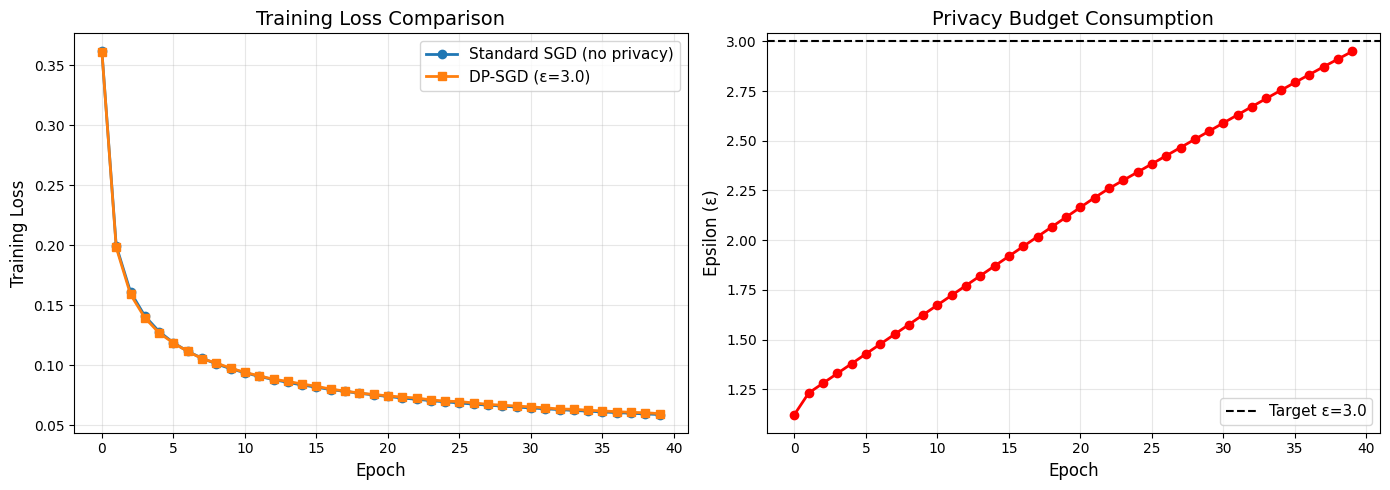


📊 Observations:
  1. DP-SGD converges slower due to noise
  2. Privacy budget (ε) increases throughout training
  3. Calibration ensures we hit target ε at end of training


In [61]:
# Visualize training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training loss
ax1.plot(losses_standard, label='Standard SGD (no privacy)', marker='o', linewidth=2)
ax1.plot(losses_dp, label=f'DP-SGD (ε={target_epsilon})', marker='s', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Training Loss', fontsize=12)
ax1.set_title('Training Loss Comparison', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Plot 2: Privacy budget over time
ax2.plot(epsilons_dp, marker='o', linewidth=2, color='red')
ax2.axhline(y=target_epsilon, color='black', linestyle='--', label=f'Target ε={target_epsilon}')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Epsilon (ε)', fontsize=12)
ax2.set_title('Privacy Budget Consumption', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Observations:")
print("  1. DP-SGD converges slower due to noise")
print("  2. Privacy budget (ε) increases throughout training")
print("  3. Calibration ensures we hit target ε at end of training")

## Part 6: Privacy-Utility Tradeoff

Let's explore how different privacy budgets affect model accuracy.

In [62]:
# Train with different privacy budgets
epsilons_to_test = [1.0, 3.0, 5.0, 10.0]
results = {}

print("Training models with different privacy budgets...\n")

for target_eps in epsilons_to_test:
  # Calibrate noise for this epsilon
  nm = calibrate_noise_multiplier(
    target_epsilon=target_eps,
    target_delta=target_delta,
    sample_rate=sample_rate,
    num_steps=total_steps,
    accountant_type="rdp",
  )

  # Train
  params, losses, eps_history = train_dp_sgd(
    params_init,
    X_train, y_train,
    batch_size=batch_size,
    n_epochs=n_epochs,
    learning_rate=learning_rate,
    l2_clip_norm=l2_clip_norm,
    noise_multiplier=nm,
    sample_rate=sample_rate,
    target_delta=target_delta,
    use_dp=True,
  )

  # Evaluate
  acc, test_loss = evaluate(params, X_test, y_test)

  results[target_eps] = {
    'accuracy': acc,
    'test_loss': test_loss,
    'final_train_loss': losses[-1],
    'noise_multiplier': nm,
  }

  print(f"ε={target_eps:5.1f}: acc={acc:.2%}, noise_mult={nm:.4f}")

print("\n✓ All models trained!")

Training models with different privacy budgets...

Epoch 5/40: loss=0.1266, ε=0.34
Epoch 10/40: loss=0.0989, ε=0.48
Epoch 15/40: loss=0.0867, ε=0.59
Epoch 20/40: loss=0.0766, ε=0.69
Epoch 25/40: loss=0.0719, ε=0.77
Epoch 30/40: loss=0.0679, ε=0.85
Epoch 35/40: loss=0.0639, ε=0.93
Epoch 40/40: loss=0.0622, ε=1.00
ε=  1.0: acc=98.33%, noise_mult=2.0316
Epoch 5/40: loss=0.1272, ε=1.38
Epoch 10/40: loss=0.0975, ε=1.62
Epoch 15/40: loss=0.0843, ε=1.87
Epoch 20/40: loss=0.0755, ε=2.12
Epoch 25/40: loss=0.0701, ε=2.34
Epoch 30/40: loss=0.0661, ε=2.55
Epoch 35/40: loss=0.0625, ε=2.75
Epoch 40/40: loss=0.0597, ε=2.95
ε=  3.0: acc=99.00%, noise_mult=0.9775
Epoch 5/40: loss=0.1270, ε=2.50
Epoch 10/40: loss=0.0974, ε=2.95
Epoch 15/40: loss=0.0840, ε=3.35
Epoch 20/40: loss=0.0751, ε=3.72
Epoch 25/40: loss=0.0699, ε=4.06
Epoch 30/40: loss=0.0658, ε=4.39
Epoch 35/40: loss=0.0622, ε=4.70
Epoch 40/40: loss=0.0594, ε=5.00
ε=  5.0: acc=99.33%, noise_mult=0.7792
Epoch 5/40: loss=0.1274, ε=4.94
Epoch 10/40

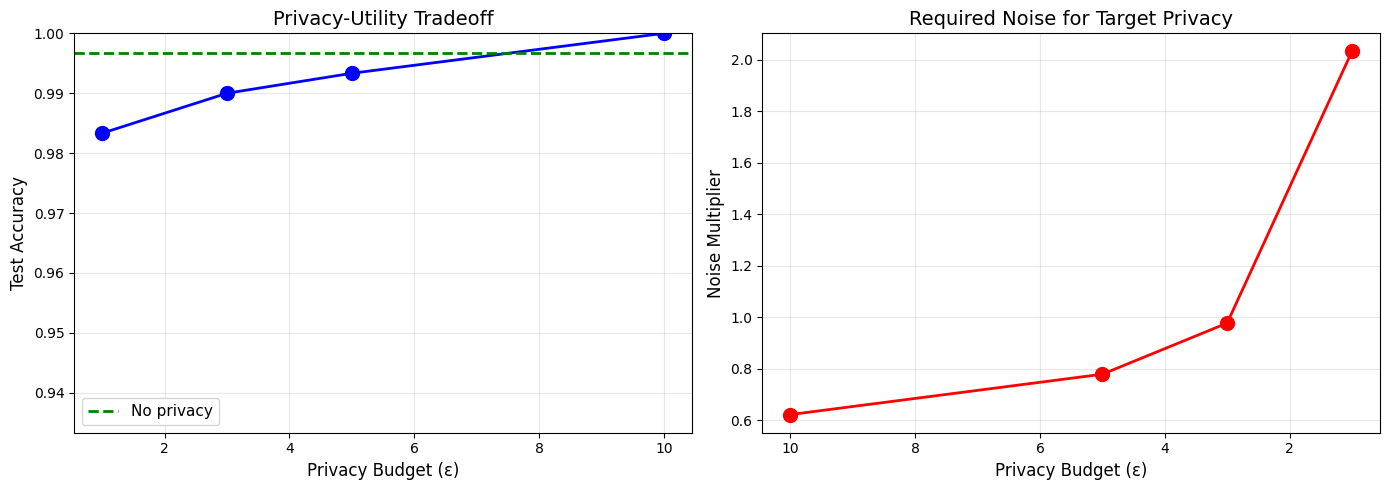


📊 Key Insights:
  1. Lower ε (better privacy) → Higher noise → Lower accuracy
  2. ε=3-5 often provides good privacy-utility balance
  3. Calibration automatically finds required noise for target ε


In [63]:
# Visualize privacy-utility tradeoff
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy vs Privacy
eps_vals = list(results.keys())
accs = [results[e]['accuracy'] for e in eps_vals]

ax1.plot(eps_vals, accs, 'o-', linewidth=2, markersize=10, color='blue')
ax1.axhline(y=acc_std, color='green', linestyle='--', linewidth=2, label='No privacy')
ax1.set_xlabel('Privacy Budget (ε)', fontsize=12)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.set_title('Privacy-Utility Tradeoff', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_ylim([min(accs) - 0.05, 1.0])

# Plot 2: Noise multiplier vs Privacy
noise_mults = [results[e]['noise_multiplier'] for e in eps_vals]

ax2.plot(eps_vals, noise_mults, 'o-', linewidth=2, markersize=10, color='red')
ax2.set_xlabel('Privacy Budget (ε)', fontsize=12)
ax2.set_ylabel('Noise Multiplier', fontsize=12)
ax2.set_title('Required Noise for Target Privacy', fontsize=14)
ax2.grid(alpha=0.3)
ax2.invert_xaxis()  # Lower epsilon on right (more private)

plt.tight_layout()
plt.show()

print("\n📊 Key Insights:")
print("  1. Lower ε (better privacy) → Higher noise → Lower accuracy")
print("  2. ε=3-5 often provides good privacy-utility balance")
print("  3. Calibration automatically finds required noise for target ε")

## Summary

### What We Built

A complete **DP-SGD training loop** that:

1. ✅ **Clips gradients** with `clipped_grad()` (Tutorial 01)
2. ✅ **Adds calibrated noise** with `add_gaussian_noise()` (Tutorial 02)
3. ✅ **Tracks privacy** with `RDPAccountant` (Tutorial 02)
4. ✅ **Calibrates noise** with `calibrate_noise_multiplier()` (Tutorial 02)
5. ✅ **Achieves target privacy** (ε, δ)-DP

### The Complete DP-SGD Pattern

```python
# 1. Calibrate noise for target privacy
noise_multiplier = calibrate_noise_multiplier(
    target_epsilon=3.0,
    target_delta=1e-5,
    sample_rate=batch_size / len(dataset),
    num_steps=total_steps,
)

# 2. Create clipped gradient function
clipped_grad_fn = clipped_grad(
    loss_fn,
    argnums=0,
    batch_argnums=1,
    l2_clip_norm=1.0,
)

# 3. Create privacy accountant
accountant = RDPAccountant()

# 4. Training loop
for epoch in range(n_epochs):
    for batch in dataloader:
        # Clipped gradients
        grads = clipped_grad_fn(params, batch)

        # Add noise
        stddev = noise_multiplier * l2_clip_norm
        noisy_grads = add_gaussian_noise(grads, stddev, generator)

        # Update
        params = optimizer_step(params, noisy_grads)

        # Track privacy
        accountant.step_poisson(noise_multiplier, sample_rate, num_steps=1)

    # Check privacy
    epsilon = accountant.get_epsilon(target_delta)
    print(f"Epoch {epoch}: ε={epsilon:.2f}")
```

### Key Takeaways

1. **Privacy-Utility Tradeoff**: Lower ε = better privacy, but lower accuracy
2. **Calibration is Essential**: Use `calibrate_noise_multiplier()` to hit target ε
3. **Accounting Matters**: Track ε throughout training with accountants
4. **Opaque Makes DP Easy**: Clean APIs for production-ready DP-SGD

### What's Next?

**Tutorial 04: DP-SGD for LoRA Fine-Tuning** (Coming soon)
- Apply DP-SGD to fine-tune LLMs
- Real-world privacy-preserving ML

---

## Exercises

1. **Experiment with noise**: Try different noise multipliers and observe effects
2. **Try PLD accounting**: Replace `RDPAccountant` with `PLDAccountant`
3. **Vary clip norm**: Test `l2_clip_norm` values (0.5, 1.0, 2.0)
4. **Compare accountants**: Plot RDP vs PLD privacy bounds
5. **Real dataset**: Apply to MNIST or CIFAR-10

---

🎉 **Congratulations!** You can now train machine learning models with differential privacy!

**Resources**:
- [Deep Learning with Differential Privacy](https://arxiv.org/abs/1607.00133) (Abadi et al., 2016)
- [Opaque Documentation](https://opaque.readthedocs.io/)
- [JAX-Privacy](https://github.com/google-deepmind/jax_privacy)